In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [3]:
energy_dataset = pd.read_csv("energy_dataset.csv")
energy_dataset

,time,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_coal-derived_gas,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_fossil_oil_shale,generation_fossil_peat,generation_geothermal,...,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_offshore,generation_wind_onshore,forecast_wind_offshore_eday_ahead,total_load_actual,price_day_ahead
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,NaN,25385.0,50.10
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,NaN,24382.0,48.10
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,NaN,22734.0,47.33
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,NaN,21286.0,42.27
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,NaN,20264.0,38.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,297.0,0.0,0.0,7634.0,2628.0,178.0,0.0,0.0,0.0,...,6073.0,63.0,95.0,85.0,277.0,0.0,3113.0,NaN,30653.0,68.85
35060,2018-12-31 20:00:00+01:00,296.0,0.0,0.0,7241.0,2566.0,174.0,0.0,0.0,0.0,...,6074.0,62.0,95.0,33.0,280.0,0.0,3288.0,NaN,29735.0,68.40
35061,2018-12-31 21:00:00+01:00,292.0,0.0,0.0,7025.0,2422.0,168.0,0.0,0.0,0.0,...,6076.0,61.0,94.0,31.0,286.0,0.0,3503.0,NaN,28071.0,66.88
35062,2018-12-31 22:00:00+01:00,293.0,0.0,0.0,6562.0,2293.0,163.0,0.0,0.0,0.0,...,6075.0,61.0,93.0,31.0,287.0,0.0,3586.0,NaN,25801.0,63.93


# Data preparation and pre-processing

In [4]:
print("Number of predictors:", energy_dataset.shape[1])

missing_values_df = energy_dataset.isnull().sum()
print(missing_values_df)

print("Dataset statistics")
energy_dataset.describe().T

Number of predictors: 25
time                                               0
generation_biomass                                19
generation_fossil_brown_coal_lignite              18
generation_fossil_coal-derived_gas                18
generation_fossil_gas                             18
generation_fossil_hard_coal                       18
generation_fossil_oil                             19
generation_fossil_oil_shale                       18
generation_fossil_peat                            18
generation_geothermal                             18
generation_hydro_pumped_storage_aggregated     35064
generation_hydro_pumped_storage_consumption       19
generation_hydro_run-of-river_and_poundage        19
generation_hydro_water_reservoir                  18
generation_marine                                 19
generation_nuclear                                17
generation_other                                  18
generation_other_renewable                        18
generation_solar     

,count,mean,std,min,25%,50%,75%,max
generation_biomass,35045.0,383.513540,85.353943,0.00,333.00,367.00,433.00,592.00
generation_fossil_brown_coal_lignite,35046.0,448.059208,354.568590,0.00,0.00,509.00,757.00,999.00
generation_fossil_coal-derived_gas,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_fossil_gas,35046.0,5622.737488,2201.830478,0.00,4126.00,4969.00,6429.00,20034.00
generation_fossil_hard_coal,35046.0,4256.065742,1961.601013,0.00,2527.00,4474.00,5838.75,8359.00
generation_fossil_oil,35045.0,298.319789,52.520673,0.00,263.00,300.00,330.00,449.00
generation_fossil_oil_shale,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_fossil_peat,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_geothermal,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_hydro_pumped_storage_aggregated,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- There are columns where all values are missing: forecast_wind_offshore_eday_ahead, generation_hydro_pumped_storage_aggregated;
- By the descriptive statistics it is also possible to ensure that the variables generation_fossil_coal-derived_gas, generation_fossil_oil_shale, generation_fossil_peat, generation_geothermal, generation_marine and generation_wind_offshore have all the values as 0.

For that reason the following columns will be removed:
[forecast_wind_offshore_eday_ahead, generation_hydro_pumped_storage_aggregated, generation_fossil_coal-derived_gas, generation_fossil_oil_shale, generation_fossil_peat, generation_geothermal, generation_marine, generation_wind_offshore].

In [5]:
features_to_remove = ['forecast_wind_offshore_eday_ahead', 'generation_hydro_pumped_storage_aggregated', 'generation_fossil_coal-derived_gas', 
                      'generation_fossil_oil_shale', 'generation_fossil_peat', 'generation_geothermal', 'generation_marine', 'generation_wind_offshore']
print(energy_dataset.columns)
energy_dataset = energy_dataset.drop(features_to_remove, axis = 1)
print(energy_dataset.columns)
energy_dataset

Index(['time', 'generation_biomass', 'generation_fossil_brown_coal_lignite',
       'generation_fossil_coal-derived_gas', 'generation_fossil_gas',
       'generation_fossil_hard_coal', 'generation_fossil_oil',
       'generation_fossil_oil_shale', 'generation_fossil_peat',
       'generation_geothermal', 'generation_hydro_pumped_storage_aggregated',
       'generation_hydro_pumped_storage_consumption',
       'generation_hydro_run-of-river_and_poundage',
       'generation_hydro_water_reservoir', 'generation_marine',
       'generation_nuclear', 'generation_other', 'generation_other_renewable',
       'generation_solar', 'generation_waste', 'generation_wind_offshore',
       'generation_wind_onshore', 'forecast_wind_offshore_eday_ahead',
       'total_load_actual', 'price_day_ahead'],
      dtype='object')
Index(['time', 'generation_biomass', 'generation_fossil_brown_coal_lignite',
       'generation_fossil_gas', 'generation_fossil_hard_coal',
       'generation_fossil_oil', 'generatio

,time,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_onshore,total_load_actual,price_day_ahead
0,2015-01-01 00:00:00+01:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10
1,2015-01-01 01:00:00+01:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10
2,2015-01-01 02:00:00+01:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33
3,2015-01-01 03:00:00+01:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27
4,2015-01-01 04:00:00+01:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,297.0,0.0,7634.0,2628.0,178.0,1.0,1135.0,4836.0,6073.0,63.0,95.0,85.0,277.0,3113.0,30653.0,68.85
35060,2018-12-31 20:00:00+01:00,296.0,0.0,7241.0,2566.0,174.0,1.0,1172.0,3931.0,6074.0,62.0,95.0,33.0,280.0,3288.0,29735.0,68.40
35061,2018-12-31 21:00:00+01:00,292.0,0.0,7025.0,2422.0,168.0,50.0,1148.0,2831.0,6076.0,61.0,94.0,31.0,286.0,3503.0,28071.0,66.88
35062,2018-12-31 22:00:00+01:00,293.0,0.0,6562.0,2293.0,163.0,108.0,1128.0,2068.0,6075.0,61.0,93.0,31.0,287.0,3586.0,25801.0,63.93


In [6]:
weather_dataset = pd.read_csv("weather.csv")
weather_dataset

,time,temperature,pressure,humidity,wind_speed
0,2015-01-01 00:00:00+01:00,272.491463,1021.3,82.4,2.0
1,2015-01-01 01:00:00+01:00,272.512700,1021.2,82.4,2.0
2,2015-01-01 02:00:00+01:00,272.151937,1021.6,82.0,2.4
3,2015-01-01 03:00:00+01:00,272.142269,1021.5,82.0,2.4
4,2015-01-01 04:00:00+01:00,272.198700,1021.5,82.0,2.4
...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,284.470000,1029.2,73.6,1.4
35060,2018-12-31 20:00:00+01:00,282.294000,1030.0,68.0,1.8
35061,2018-12-31 21:00:00+01:00,280.850000,1029.8,71.4,2.6
35062,2018-12-31 22:00:00+01:00,279.718000,1030.2,70.0,2.8


In [7]:
print("Number of predictors:", weather_dataset.shape[1])

missing_values_df = weather_dataset.isnull().sum()
print(missing_values_df)

print("Dataset statistics")
weather_dataset.describe().T

Number of predictors: 5
time           0
temperature    0
pressure       0
humidity       0
wind_speed     0
dtype: int64
Dataset statistics


,count,mean,std,min,25%,50%,75%,max
temperature,35064.0,289.706862,7.251796,272.006,284.098877,289.0362,295.1005,309.048
pressure,35064.0,1017.297872,6.363845,999.500,1013.475000,1017.0000,1021.0000,1035.500
humidity,35064.0,68.033025,14.814871,22.600,56.750000,69.6000,80.0000,100.000
wind_speed,35064.0,2.442944,1.276415,0.000,1.400000,2.2000,3.2000,8.500


In [8]:
df = pd.merge(energy_dataset, weather_dataset, on="time", how="inner")
df['time'] = pd.to_datetime(df['time'], utc = True)
df.set_index('time', inplace=True)
df = df.asfreq('h')
df

,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_onshore,total_load_actual,price_day_ahead,temperature,pressure,humidity,wind_speed
time,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10,272.491463,1021.3,82.4,2.0
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10,272.512700,1021.2,82.4,2.0
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33,272.151937,1021.6,82.0,2.4
2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27,272.142269,1021.5,82.0,2.4
2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41,272.198700,1021.5,82.0,2.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 18:00:00+00:00,297.0,0.0,7634.0,2628.0,178.0,1.0,1135.0,4836.0,6073.0,63.0,95.0,85.0,277.0,3113.0,30653.0,68.85,284.470000,1029.2,73.6,1.4
2018-12-31 19:00:00+00:00,296.0,0.0,7241.0,2566.0,174.0,1.0,1172.0,3931.0,6074.0,62.0,95.0,33.0,280.0,3288.0,29735.0,68.40,282.294000,1030.0,68.0,1.8
2018-12-31 20:00:00+00:00,292.0,0.0,7025.0,2422.0,168.0,50.0,1148.0,2831.0,6076.0,61.0,94.0,31.0,286.0,3503.0,28071.0,66.88,280.850000,1029.8,71.4,2.6


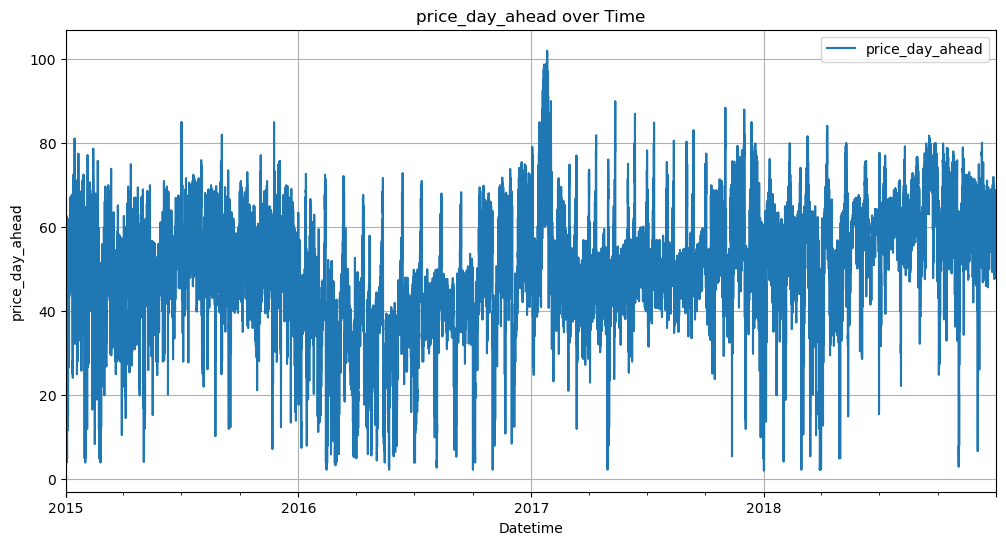

In [9]:
df.plot(y='price_day_ahead', figsize=(12, 6), title='price_day_ahead over Time')
plt.xlabel('Datetime')
plt.ylabel('price_day_ahead')
plt.grid(True)
plt.show()

From the time series graphic we can see the evolution of price_day_ahead over time. Is it possible to verify seasonal patterns over the years but we will plot the rolling mean and standard derivation using different window lengths in order to highlight recurring patterns.

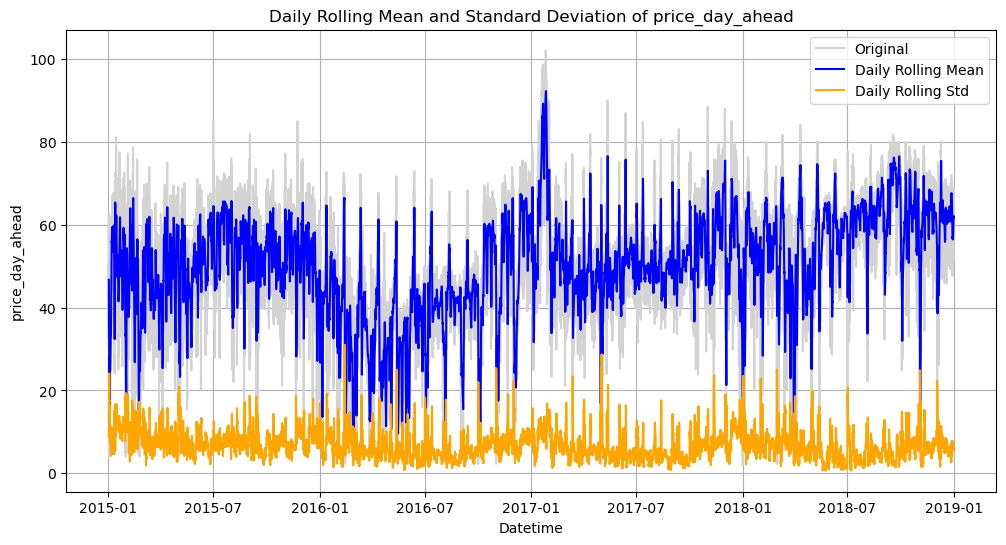

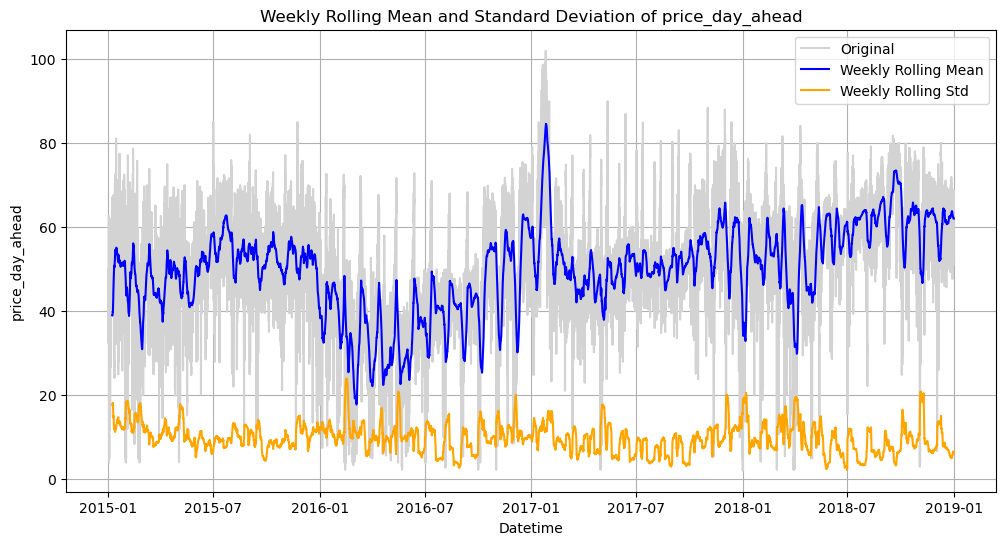

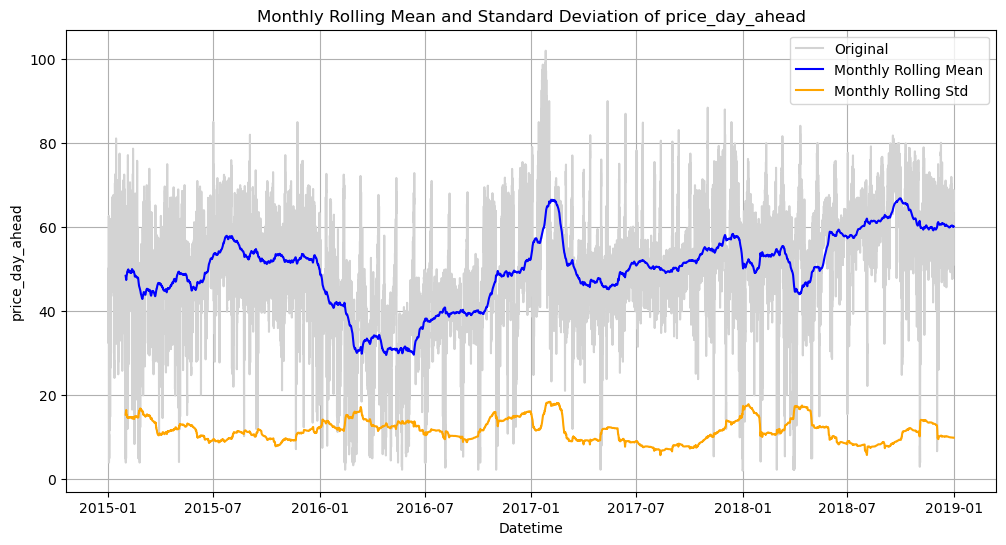

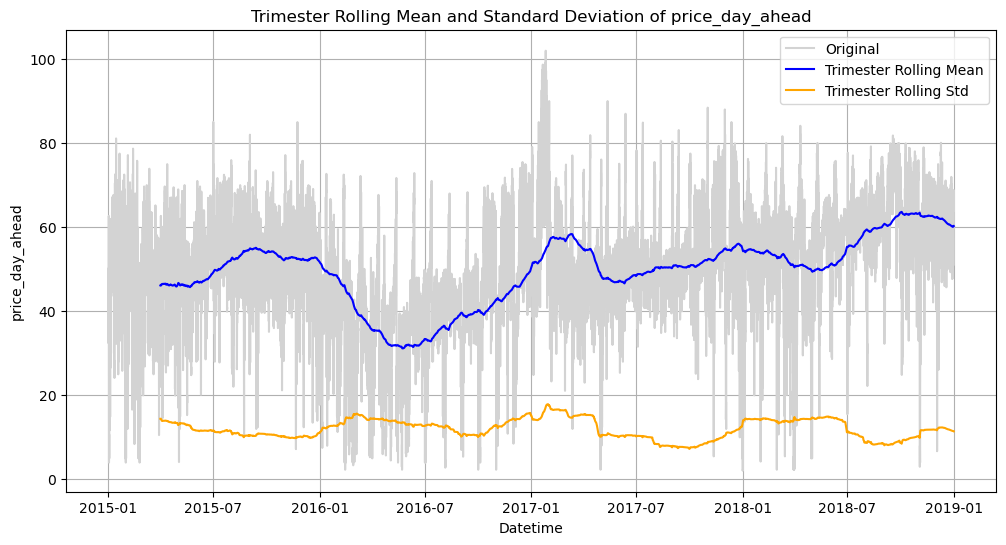

In [10]:
time_windows = {
    24: 'Daily',
    168: 'Weekly',    
    720: 'Monthly',    
    2160: 'Trimester'
}

for time_win, freq in time_windows.items():
    rolling_mean = df['price_day_ahead'].rolling(window=time_win).mean()
    rolling_std = df['price_day_ahead'].rolling(window=time_win).std()
    
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['price_day_ahead'], color='lightgray', label='Original')
    plt.plot(df.index, rolling_mean, color='blue', label=f'{freq} Rolling Mean')
    plt.plot(df.index, rolling_std, color='orange', label=f'{freq} Rolling Std')
    
    plt.title(f'{freq} Rolling Mean and Standard Deviation of price_day_ahead')
    plt.xlabel('Datetime')
    plt.ylabel('price_day_ahead')
    plt.legend()
    plt.grid(True)
    plt.show()

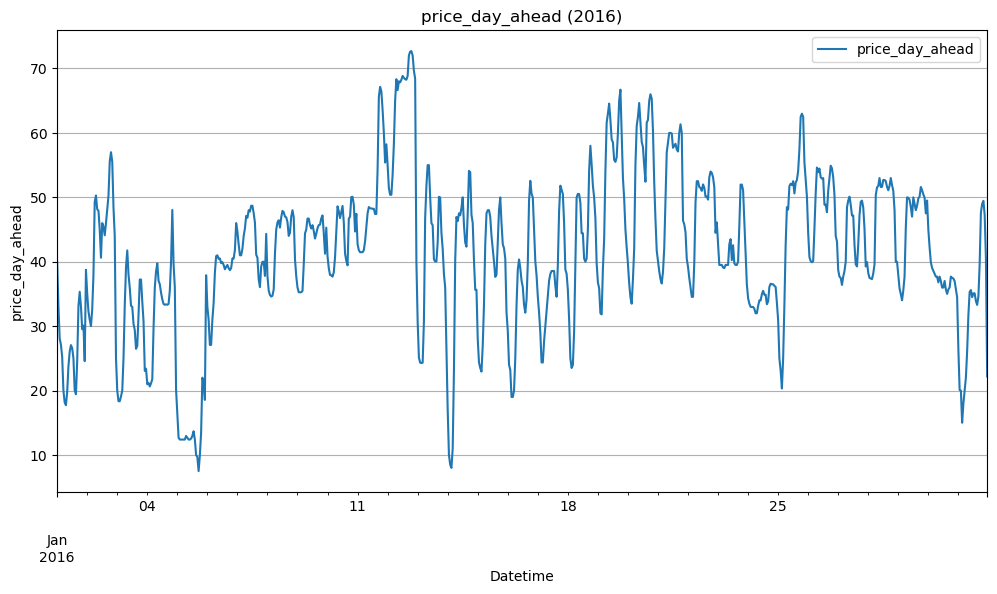

In [11]:
## Comentário da sazonalidade

df.loc['2016-01'].plot(
    y='price_day_ahead',
    figsize=(12, 6),
    title='price_day_ahead (2016)'
)

plt.xlabel('Datetime')
plt.ylabel('price_day_ahead')
plt.grid(True)
plt.show()

##### Missing Values

In a time series, missing values can represent gaps or interruptions, which may distort analysis and forecasting if not properly handled. To address this, we will use nearest interpolation.

Nearest Interpolation works by filling missing values with the closest observed value, combining the effects of both forward and backward filling. This approach helps to:
- Maintain the consistency of trends and tendencies in the data
- Avoid introducing artificial jumps or smoothing that could distort short-term dynamics

In [12]:
print('Dataset missing values')
missing_values_df = df.isnull().sum()
print(missing_values_df)

df = df.interpolate(method='nearest')

print()
print('Dataset after missing values being filled using Nearest Interpolation')
print(df.isnull().sum())

Dataset missing values
generation_biomass                             19
generation_fossil_brown_coal_lignite           18
generation_fossil_gas                          18
generation_fossil_hard_coal                    18
generation_fossil_oil                          19
generation_hydro_pumped_storage_consumption    19
generation_hydro_run-of-river_and_poundage     19
generation_hydro_water_reservoir               18
generation_nuclear                             17
generation_other                               18
generation_other_renewable                     18
generation_solar                               18
generation_waste                               19
generation_wind_onshore                        18
total_load_actual                              36
price_day_ahead                                 0
temperature                                     0
pressure                                        0
humidity                                        0
wind_speed                 

##### Data Split
The final 12 months will be used as test set. The remaining data will be used as training set.

In [13]:
# Number of months to use as test set
test_size = 365 * 24 - 1

train = df.iloc[:-test_size]  # all rows except last 24 months
test = df.iloc[-test_size:]   # last 24 months

print(f"Training set shape: {train.shape}")
print(f"Test set shape: {test.shape}")
print(f"Training period: {train.index.min()} to {train.index.max()}")
print(f"Test period: {test.index.min()} to {test.index.max()}")

X_train = train.drop(columns=['price_day_ahead'])
y_train = train['price_day_ahead']

X_test = test.drop(columns=['price_day_ahead'])
y_test = test['price_day_ahead']

Training set shape: (26305, 20)
Test set shape: (8759, 20)
Training period: 2014-12-31 23:00:00+00:00 to 2017-12-31 23:00:00+00:00
Test period: 2018-01-01 00:00:00+00:00 to 2018-12-31 22:00:00+00:00


# Modeling

For evaluation purposes, all optimized models will be stored in a map to be evaluated latter.

In [14]:
models = {}

### Statistical models

##### Stationary Testing and ACF/PACF analysis

In [15]:
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(df['price_day_ahead'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -12.288647154284345
p-value: 7.919257782286934e-23


Stationary time series. p-value < 0.05, H0 rejected.

Differencing is not required.

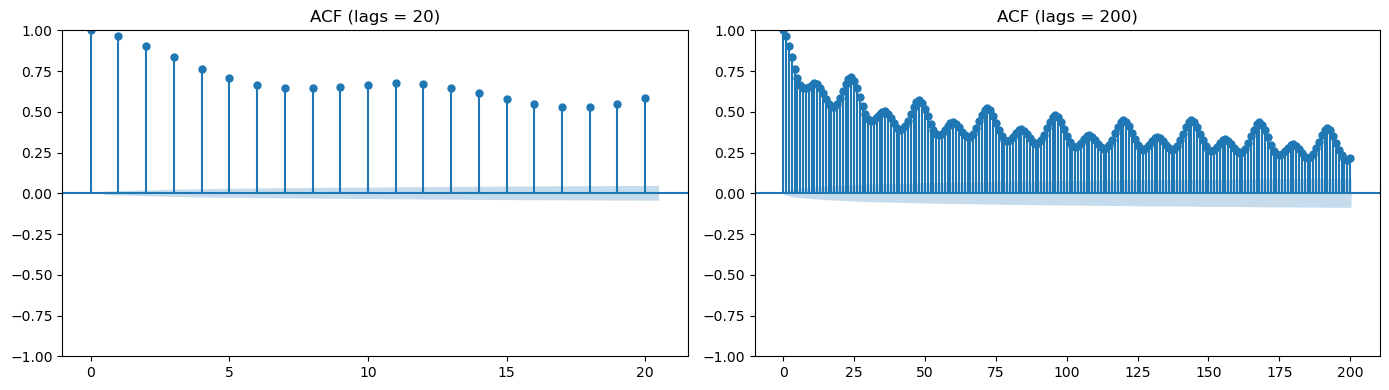

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

series = df['price_day_ahead']


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Short-term ACF (non-seasonal structure)
plot_acf(series, lags=20, ax=axes[0])
axes[0].set_title("ACF (lags = 20)")

# Long-term ACF (seasonality detection)
plot_acf(series, lags=200, ax=axes[1])
axes[1].set_title("ACF (lags = 200)")

plt.tight_layout()
plt.show()

##### ACF interpretation
- The autocorrelation function exhibits a slow decay across lags, with correlations remaining significantly positive for many lags.
- All lags are significantly positive.
- When we expand the number of lags, is it possible to observe a wave repeating pattern, which can suggest the existence of seasonality in the time series. 

##### Conclusions
From the ACF plot, we can conclud that this time series does not represent a MA(q) process. On a MA(q) series coeficients would become abruptly non-significant in ACF, indicating the order of the Moving Average series. 

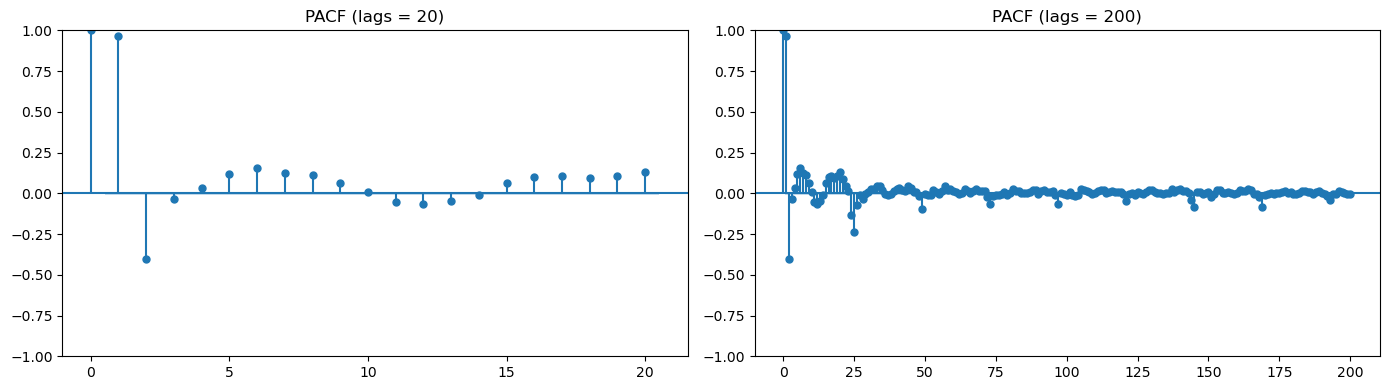

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Short-term ACF (non-seasonal structure)
plot_pacf(series, lags=20, ax=axes[0])
axes[0].set_title("PACF (lags = 20)")

# Long-term ACF (seasonality detection)
plot_pacf(series, lags=200, ax=axes[1])
axes[1].set_title("PACF (lags = 200)")

plt.tight_layout()
plt.show()

##### PACF interpretation
- The PACF shows coeficients becoming abruptly non-significant at lag 2, indicating an autoregressive structure of order 2.
- When extending the PACF to a larger number of lags, a significant spike at lag 24 is observed, revealing the presence of daily seasonality in the hourly time series.
-Beyond the seasonal lag, partial autocorrelations remain close to zero, suggesting that higher-order autoregressive terms are unnecessary.

##### Conclusions
The PACF analysis indicates that the series follows an AR(2) process.

##### Seasonal P and Q analysis
- The presence of a single significant spike at the seasonal lag (24) in the PACF indicates a seasonal autoregressive component of order 1 (P = 1).
- No abrupt cutoff is observed in the ACF at the seasonal lag or its multiples, which suggests the absence of a seasonal moving-average component (Q = 0).
- The seasonal dependence therefore appears to be captured by a seasonal AR term rather than a seasonal MA term.

D and d analysis

In [19]:
# # Commented due to long running time | Total fit time: 870.239s

# import pmdarima as pm
# from statsmodels.tsa.statespace.kalman_filter import MEMORY_CONSERVE

# auto_sarima = pm.auto_arima(
#     y_train.loc['2017'],
#     start_p=0, max_p=2,
#     start_q=0, max_q=0,
#     start_P=0, max_P=3,
#     start_Q=0, max_Q=1,
#     d=0, D=0,
#     seasonal=True,
#     m=24,
#     stepwise=False,
#     n_jobs=-1,
#     trace=True,
#     error_action='ignore',
#     suppress_warnings=True,
#     sarimax_kwargs={'conserve_memory': MEMORY_CONSERVE}
# )


# # best (2,0,0)(3,0,0)[24]

best: (2,0,0)(3,0,0)[24]

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# from auto_arima results (2,0,0)(3,0,0)[24]

order=(2,0,0)
seasonal_order=(3,0,0,24)

# SARIMA Model
sarima_model = SARIMAX(
    y_train.loc['2017'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# 1-step ahead forecast (next hour)
sarima_forecast_1h = sarima_model.get_forecast(steps=1).predicted_mean

# 24-step ahead forecast (next day)
sarima_forecast_24h = sarima_model.get_forecast(steps=24).predicted_mean

# Store SARIMA model
models['SARIMA'] = sarima_model

In [23]:
# SARIMAX Model (with exogenous variables)

sarimax_model = SARIMAX(
    y_train.loc['2017'],
    order=order,
    seasonal_order=seasonal_order,
    exog=X_train.loc['2017'],
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecasts with exogenous variables
sarimax_forecast_1h = sarimax_model.get_forecast(
    steps=1, exog=X_test.iloc[:1]
).predicted_mean
sarimax_forecast_1h.index = y_test.iloc[:1].index  # Align index

sarimax_forecast_24h = sarimax_model.get_forecast(
    steps=24, exog=X_test.iloc[:24]
).predicted_mean
sarimax_forecast_24h.index = y_test.iloc[:24].index  # Align index

# Store SARIMAX model
models['SARIMAX'] = sarimax_model

C:\Users\jorge\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


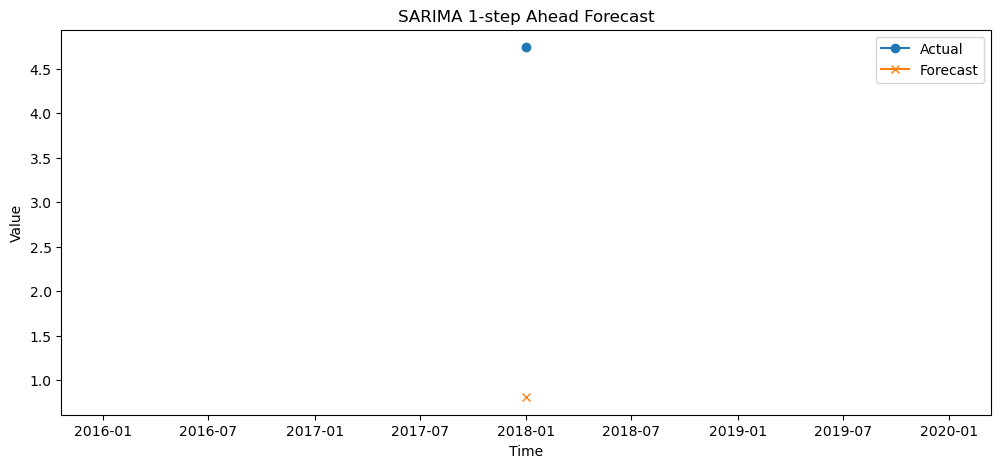

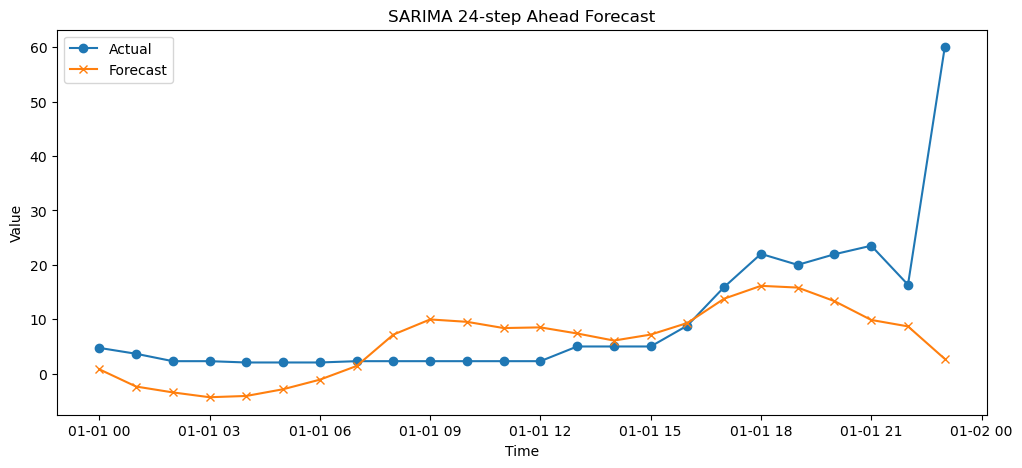

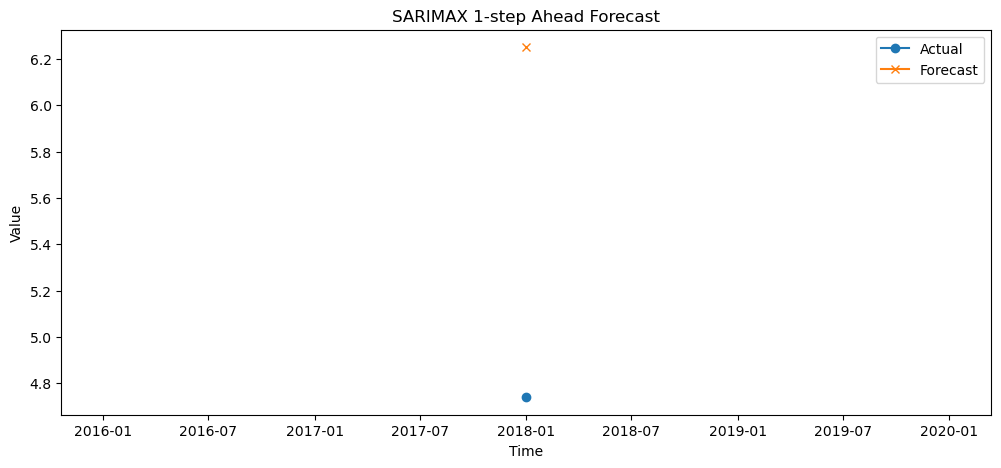

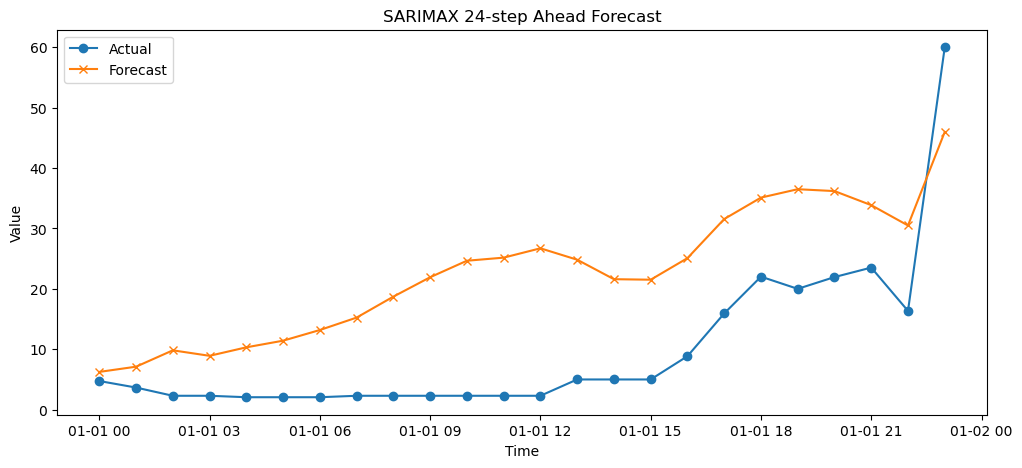

In [24]:
def plot_forecast(actual, forecast, title):
    plt.figure(figsize=(12,5))
    plt.plot(actual.index, actual, label='Actual', marker='o')
    plt.plot(forecast.index, forecast, label='Forecast', marker='x')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

# SARIMA Plots
plot_forecast(y_test.iloc[:1], sarima_forecast_1h, 'SARIMA 1-step Ahead Forecast')
plot_forecast(y_test.iloc[:24], sarima_forecast_24h, 'SARIMA 24-step Ahead Forecast')

# SARIMAX Plots
plot_forecast(y_test.iloc[:1], sarimax_forecast_1h, 'SARIMAX 1-step Ahead Forecast')
plot_forecast(y_test.iloc[:24], sarimax_forecast_24h, 'SARIMAX 24-step Ahead Forecast')

#### Machine Learning models

In order to train ML models, sliding-window datasets will be used. It will be made a comparison between the window sizes using a baseline_model to make the decision of which sliding-window will be used for 1 hour and 24 hours predictions.

In [29]:
def slideWindow(time_series, window_in, horizon):
    
    if (len(time_series) - window_in - horizon + 1) <= 0:
        raise ValueError("Time series too short for window size or horizon.")
        
    d = time_series.values
    X, y = [], []
    
    for start in range(len(time_series)-window_in):
        end = start + window_in
        out = end + horizon
        X.append(d[start:end].reshape(-1))
        y.append(d[end:out].ravel()) # ravel() is equivalent to reshape(-1): returns contiguous flattened array
    
    cols_x = [f'x{i}' for i in range(1, window_in+1)]
    cols_y = [f'y{i}' for i in range(1, horizon+1)]
    
    df_X = pd.DataFrame(X, columns=cols_x)
    df_y = pd.DataFrame(y, columns=cols_y)
    
    return pd.concat([df_X, df_y], axis=1).dropna()




In [30]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor

baseline_model = RandomForestRegressor(n_estimators=20, random_state=42)

window_sizes = [24, 48, 72]
window_scores = {}

for w in window_sizes:
    print('Window', w, '...')
    data = slideWindow(df['price_day_ahead'], w, horizon=1)
    X = data[[f'x{i}' for i in range(1, w+1)]]
    y = data['y1'].values  # flatten
    scores = cross_val_score(
        baseline_model, X, y,
        cv=TimeSeriesSplit(5),
        scoring='neg_root_mean_squared_error'
    )
    window_scores[w] = -scores.mean()

print(window_scores)

Window 24 ...
Window 48 ...
Window 72 ...
{24: np.float64(3.4192988346896036), 48: np.float64(3.450409982233663), 72: np.float64(3.382293461286826)}


Based on cross-validation results, both the 24-hour and 72-hour sliding windows achieve similarly low RMSE values, with only a minimal difference between them. Given that the 24-hour window uses fewer input features, it offers a simpler model that trains faster and focuses on the most recent, and likely most relevant, data patterns. Therefore, despite the marginally better RMSE of the 72-hour window, the 24-hour window is selected as the baseline for its balance of efficiency, simplicity, and comparable predictive performance.

In [60]:
window_sizes = [24, 48, 72, 96, 168]

for w in window_sizes:
    print('Window', w, '...')
    data = slideWindow(df['price_day_ahead'], w, horizon=24)
    X = data[[f'x{i}' for i in range(1, w+1)]]
    y = data['y1'].values  # flatten
    scores = cross_val_score(
        baseline_model, X, y,
        cv=TimeSeriesSplit(5),
        scoring='neg_root_mean_squared_error'
    )
    window_scores[w] = -scores.mean()

print(window_scores)

Window 24 ...
Window 48 ...
Window 72 ...
Window 96 ...
Window 168 ...
{24: np.float64(3.3984846685686705), 48: np.float64(3.4346478839727275), 72: np.float64(3.386416138354547), 96: np.float64(3.47805066536331), 168: np.float64(3.442905126651347)}


For the same reasons described above, for 24h forecasting, 24-hour window will be used to train the models on the next step.

In [66]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

window_in = 24
horizons = [1,24]  # 1-step ahead

tscv = TimeSeriesSplit(n_splits=5)

ML_models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Bagging": BaggingRegressor(n_estimators=50, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=50, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=50, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=50, random_state=42, verbosity=0),
    "LGBM": lgb.LGBMRegressor(n_estimators=50, random_state=42)
}

results = {}

for h in horizons:

    print('---------Models for', h, 'h predictions----------')
    # Create sliding-window dataset
    data = slideWindow(df['price_day_ahead'], window_in, h)
    X = data[[f'x{i}' for i in range(1, window_in+1)]].values
    y = data['y1'].values
    
    for name, model in ML_models.items():
        scores = cross_val_score(model, X, y, cv=tscv,
                                 scoring='neg_root_mean_squared_error',
                                 n_jobs=-1)  # parallelize
        results[name] = -scores.mean()
        print(f"{name}: RMSE = {results[name]:.3f}")

---------Models for 1 h predictions----------
LinearRegression: RMSE = 3.083
DecisionTree: RMSE = 4.764
KNN: RMSE = 5.256
SVR: RMSE = 4.978
Bagging: RMSE = 3.344
GradientBoosting: RMSE = 3.609
RandomForest: RMSE = 3.337
XGBoost: RMSE = 3.531
LGBM: RMSE = 3.409
---------Models for 24 h predictions----------
LinearRegression: RMSE = 3.084
DecisionTree: RMSE = 4.760
KNN: RMSE = 5.258
SVR: RMSE = 4.980
Bagging: RMSE = 3.355
GradientBoosting: RMSE = 3.613
RandomForest: RMSE = 3.339
XGBoost: RMSE = 3.535
LGBM: RMSE = 3.418


In [67]:
# # Commented due to long time execution

# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestRegressor

# window_in = 24
# horizon = 1  # predict next 24 hours
# tscv = TimeSeriesSplit(n_splits=5)

# data = slideWindow(df['price_day_ahead'], window_in, horizon)
# X = data[[f'x{i}' for i in range(1, window_in+1)]].values
# y = data[[f'y{i}' for i in range(1, horizon+1)]].values  # multi-output

# # -----------------------------
# # Define models and grids
# # -----------------------------
# models = {
#     "RandomForest": {
#         "estimator": RandomForestRegressor(random_state=42),
#         "param_grid": {
#             'n_estimators': [50, 100, 200],
#             'max_depth': [None, 5, 10, 20],
#             'min_samples_split': [2, 5],
#             'min_samples_leaf': [1, 2]
#         }
#     },
#     "GradientBoosting": {
#         "estimator": GradientBoostingRegressor(random_state=42),
#         "param_grid": {
#             'n_estimators': [50, 100, 200],
#             'learning_rate': [0.01, 0.05, 0.1],
#             'max_depth': [3, 5, 7],
#             'subsample': [0.6, 0.8, 1.0]
#         }
#     },
#     "XGBoost": {
#         "estimator": xgb.XGBRegressor(random_state=42, verbosity=0),
#         "param_grid": {
#             'n_estimators': [50, 100, 200],
#             'learning_rate': [0.01, 0.05, 0.1],
#             'max_depth': [3, 5, 7],
#             'subsample': [0.6, 0.8, 1.0]
#         }
#     },
#     "LGBM": {
#         "estimator": lgb.LGBMRegressor(random_state=42),
#         "param_grid": {
#             'n_estimators': [50, 100, 200],
#             'learning_rate': [0.01, 0.05, 0.1],
#             'num_leaves': [31, 50, 100],
#             'subsample': [0.6, 0.8, 1.0]
#         }
#     }
# }

# # -----------------------------
# # Grid Search with TimeSeriesSplit
# # -----------------------------
# best_models = {}

# for name, info in models.items():
#     print(f"----- Grid Search for {name} -----")
    
#     grid = GridSearchCV(
#         estimator=info['estimator'],
#         param_grid=info['param_grid'],
#         cv=tscv,
#         scoring='neg_root_mean_squared_error',
#         n_jobs=-1,
#         verbose=2
#     )
    
#     grid.fit(X, y)
    
#     print(f"Best params for {name}: {grid.best_params_}")
#     print(f"Best CV RMSE: {-grid.best_score_:.3f}\n")
    
#     best_models[name] = grid.best_estimator_


----- Grid Search for RandomForest -----
Fitting 5 folds for each of 48 candidates, totalling 240 fits


C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best params for RandomForest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE: 3.285

----- Grid Search for GradientBoosting -----
Fitting 5 folds for each of 81 candidates, totalling 405 fits


C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Best params for GradientBoosting: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE: 3.360

----- Grid Search for XGBoost -----
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params for XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.6}
Best CV RMSE: 3.395

----- Grid Search for LGBM -----
Fitting 5 folds for each of 81 candidates, totalling 405 fits


C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002479 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 35040, number of used features: 24
[LightGBM] [Info] Start training from score 49.876514
Best params for LGBM: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 50, 'subsample': 0.6}
Best CV RMSE: 3.341



----- Grid Search for RandomForest -----
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best params for RandomForest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best CV RMSE: 3.285

----- Grid Search for GradientBoosting -----

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best params for GradientBoosting: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Best CV RMSE: 3.360

----- Grid Search for XGBoost -----

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best params for XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.6}

Best CV RMSE: 3.395

----- Grid Search for LGBM -----

Fitting 5 folds for each of 81 candidates, totalling 405 fits

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002479 seconds.

You can set `force_col_wise=true` to remove the overhead.

[LightGBM] [Info] Total Bins 6120

[LightGBM] [Info] Number of data points in the train set: 35040, number of used features: 24

[LightGBM] [Info] Start training from score 49.876514

Best params for LGBM: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 50, 'subsample': 0.6}

Best CV RMSE: 3.341

In [26]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

gb_final = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

xgb_final = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.6,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

lgbm_final = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=50,
    subsample=0.6,
    random_state=42,
    n_jobs=-1
)


best_models = {
    "RandomForest": rf_final,
    "GradientBoosting": gb_final,
    "XGBoost": xgb_final,
    "LGBM": lgbm_final
}

In [39]:
from sklearn.preprocessing import MinMaxScaler

window_in = 24
horizon_1h = 1
horizon_24h = 24

# --- Sliding-window datasets ---
train_1h = slideWindow(train['price_day_ahead'], window_in, horizon_1h)
X_train_1h = train_1h[[f'x{i}' for i in range(1, window_in+1)]].values
y_train_1h = train_1h['y1'].values

train_24h = slideWindow(train['price_day_ahead'], window_in, horizon_24h)
X_train_24h = train_24h[[f'x{i}' for i in range(1, window_in+1)]].values
y_train_24h = train_24h[[f'y{i}' for i in range(1, horizon_24h+1)]].values

# --- Scalers ---
scaler_1h = MinMaxScaler()
X_train_scaled_1h = scaler_1h.fit_transform(X_train_1h)

scaler_24h = MinMaxScaler()
X_train_scaled_24h = scaler_24h.fit_transform(X_train_24h)


In [40]:
# LONG TIME EXECUTION (~ 1 hour)

models_1h = {}
models_24h = {}

from sklearn.multioutput import MultiOutputRegressor

for name, model in best_models.items():
    # 1-hour ahead
    m1 = model.__class__(**model.get_params())
    m1.fit(X_train_scaled_1h, y_train_1h)
    models_1h[name] = m1

    # 24-hour ahead
    if name == "RandomForest":
        # RF supports multi-output natively
        m24 = model.__class__(**model.get_params())
    else:
        # Wrap others
        m24 = MultiOutputRegressor(
            model.__class__(**model.get_params())
        )

    m24.fit(X_train_scaled_24h, y_train_24h)
    models_24h[name] = m24


# --- Prepare test input ---
last_24h_train = train['price_day_ahead'].iloc[-window_in:]
X_test_init = last_24h_train.values.reshape(1, -1)

# --- Scale test input ---
X_test_scaled_1h = scaler_1h.transform(X_test_init)
X_test_scaled_24h = scaler_24h.transform(X_test_init)

# --- 1-hour predictions ---
pred_1h = {}
true_1h = y_test.iloc[0]

for name, model in models_1h.items():
    pred_1h[name] = float(model.predict(X_test_scaled_1h)[0])

# --- 24-hour predictions ---
pred_24h = {}
true_24h = y_test.iloc[:24].values

for name, model in models_24h.items():
    pred_24h[name] = model.predict(X_test_scaled_24h).ravel()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001719 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 26281, number of used features: 24
[LightGBM] [Info] Start training from score 47.402486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 26258, number of used features: 24
[LightGBM] [Info] Start training from score 47.431015
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 26258, number of used features: 24
[LightGBM] [Info] Start t

C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packag

In [41]:
df_1h_compare = pd.DataFrame({
    'True': [true_1h],
    **pred_1h
})

df_1h_compare

,True,RandomForest,GradientBoosting,XGBoost,LGBM
0,4.74,6.177308,5.598017,6.508994,4.822012


In [45]:
df_24h_compare = pd.DataFrame(
    pred_24h,
    index=y_test.index[:24]
)

df_24h_compare['True'] = true_24h

df_24h_compare

,RandomForest,GradientBoosting,XGBoost,LGBM,True
time,,,,,
2018-01-01 00:00:00+00:00,7.373219,5.242094,5.886302,5.036063,4.74
2018-01-01 01:00:00+00:00,7.327239,4.566674,6.939247,5.226254,3.66
2018-01-01 02:00:00+00:00,7.744603,5.078564,8.433393,7.027515,2.30
2018-01-01 03:00:00+00:00,9.025351,6.428104,6.513278,8.008237,2.30
2018-01-01 04:00:00+00:00,10.927669,9.843280,10.490593,8.699456,2.06
2018-01-01 05:00:00+00:00,12.979767,13.157899,14.960390,12.842674,2.06
2018-01-01 06:00:00+00:00,14.603038,15.480485,16.675570,18.388604,2.06
2018-01-01 07:00:00+00:00,15.591886,18.745133,19.978849,19.945811,2.30
2018-01-01 08:00:00+00:00,16.242664,20.720540,20.376604,20.083243,2.30


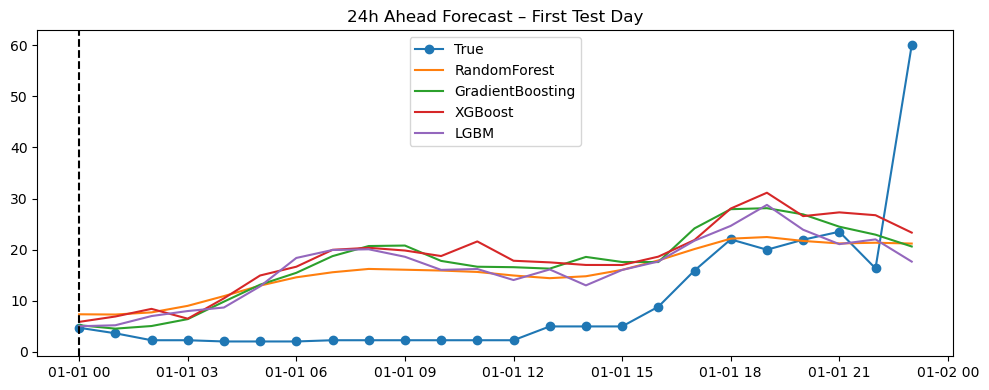

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.index[:24], true_24h, label="True", marker='o')

for name, pred in pred_24h.items():
    plt.plot(y_test.index[:24], pred, label=name)

plt.axvline(y_test.index[0], color='k', linestyle='--')
plt.title("24h Ahead Forecast – First Test Day")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
models.update(best_models)
len(models)

6

In [48]:
print(models)

{'SARIMA': <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper object at 0x0000023A39D2DE00>, 'SARIMAX': <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper object at 0x0000023A39D2F950>, 'RandomForest': RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, n_estimators=200,
                      n_jobs=-1, random_state=42), 'GradientBoosting': GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200,
                          random_state=42, subsample=0.8), 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
          

#### Deep Learning models

## Model Evaluation

1-hour ahead metrics:


,MAE,RMSE,MAPE
RandomForest,1.437308,1.437308,30.322961
GradientBoosting,0.858017,0.858017,18.101620
XGBoost,1.768994,1.768994,37.320541
LGBM,0.082012,0.082012,1.730207
SARIMA,3.931301,3.931301,82.938837
SARIMAX,1.510306,1.510306,31.862993
SeasonalNaive,15.090000,15.090000,318.354430


24-hour ahead metrics:


,MAE,RMSE,MAPE
RandomForest,9.332458,12.049840,275.631903
GradientBoosting,10.773263,13.429496,301.883807
XGBoost,11.678409,13.808704,332.563363
LGBM,10.247624,13.292274,292.825442
SARIMA,7.293854,13.039759,138.695865
SARIMAX,13.898598,15.045579,374.761152
SeasonalNaive,27.764583,29.487856,706.814911


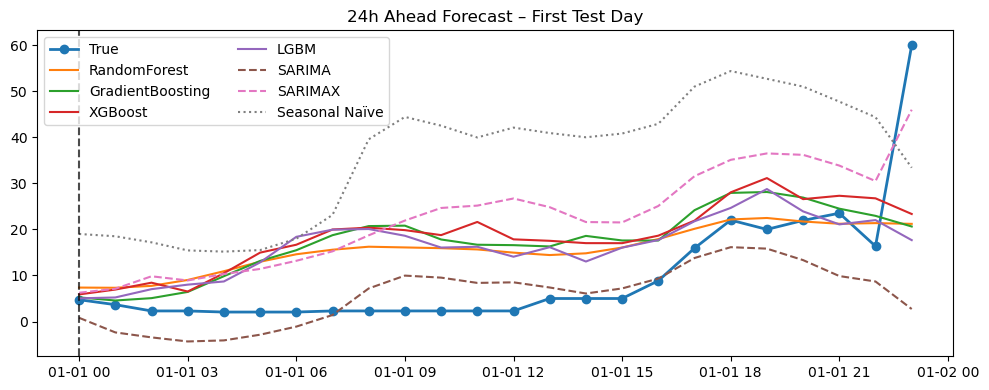

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1-hour ahead ---
metrics_1h = {}

# Add ML model predictions
for name, pred in pred_1h.items():
    metrics_1h[name] = {
        'MAE': mean_absolute_error([true_1h], [pred]),
        'RMSE': np.sqrt(mean_squared_error([true_1h], [pred])),
        'MAPE': np.mean(np.abs((true_1h - pred) / true_1h)) * 100
    }

# Add SARIMA
metrics_1h['SARIMA'] = {
    'MAE': mean_absolute_error([true_1h], [sarima_forecast_1h.values[0]]),
    'RMSE': np.sqrt(mean_squared_error([true_1h], [sarima_forecast_1h.values[0]])),
    'MAPE': np.mean(np.abs((true_1h - sarima_forecast_1h.values[0]) / true_1h)) * 100
}

# Add SARIMAX
metrics_1h['SARIMAX'] = {
    'MAE': mean_absolute_error([true_1h], [sarimax_forecast_1h.values[0]]),
    'RMSE': np.sqrt(mean_squared_error([true_1h], [sarimax_forecast_1h.values[0]])),
    'MAPE': np.mean(np.abs((true_1h - sarimax_forecast_1h.values[0]) / true_1h)) * 100
}

# --- 1-hour ahead Seasonal Naïve ---
seasonal_naive_1h = y_train.iloc[-seasonal_lag]
metrics_1h['SeasonalNaive'] = {
    'MAE': mean_absolute_error([true_1h], [seasonal_naive_1h]),
    'RMSE': np.sqrt(mean_squared_error([true_1h], [seasonal_naive_1h])),
    'MAPE': np.mean(np.abs((true_1h - seasonal_naive_1h) / true_1h)) * 100
}

df_metrics_1h = pd.DataFrame(metrics_1h).T  # transpose for readability

# --- 24-hour ahead ---
metrics_24h = {}

# ML models
for name, pred in pred_24h.items():
    metrics_24h[name] = {
        'MAE': mean_absolute_error(true_24h, pred),
        'RMSE': np.sqrt(mean_squared_error(true_24h, pred)),
        'MAPE': np.mean(np.abs((true_24h - pred) / true_24h)) * 100
    }

# SARIMA
metrics_24h['SARIMA'] = {
    'MAE': mean_absolute_error(true_24h, sarima_forecast_24h.values),
    'RMSE': np.sqrt(mean_squared_error(true_24h, sarima_forecast_24h.values)),
    'MAPE': np.mean(np.abs((true_24h - sarima_forecast_24h.values) / true_24h)) * 100
}

# SARIMAX
metrics_24h['SARIMAX'] = {
    'MAE': mean_absolute_error(true_24h, sarimax_forecast_24h.values),
    'RMSE': np.sqrt(mean_squared_error(true_24h, sarimax_forecast_24h.values)),
    'MAPE': np.mean(np.abs((true_24h - sarimax_forecast_24h.values) / true_24h)) * 100
}

df_metrics_24h = pd.DataFrame(metrics_24h).T


seasonal_lag = 24
# --- 24-hour ahead Seasonal Naïve ---
seasonal_naive_24h = y_train.iloc[-seasonal_lag*2:-seasonal_lag].values
metrics_24h['SeasonalNaive'] = {
    'MAE': mean_absolute_error(true_24h, seasonal_naive_24h),
    'RMSE': np.sqrt(mean_squared_error(true_24h, seasonal_naive_24h)),
    'MAPE': np.mean(np.abs((true_24h - seasonal_naive_24h) / true_24h)) * 100
}

df_metrics_24h = pd.DataFrame(metrics_24h).T

df_metrics_1h.to_csv("metrics_1h.csv")
df_metrics_24h.to_csv("metrics_24h.csv")

# df_metrics_1h = pd.read_csv("metrics_1h.csv")
# df_metrics_24h = pd.read_csv("metrics_24h.csv")

# --- Display ---
print("1-hour ahead metrics:")
display(df_metrics_1h)

print("24-hour ahead metrics:")
display(df_metrics_24h)

plt.figure(figsize=(10,4))

# True values
plt.plot(y_test.index[:24], true_24h, label="True", marker='o', linewidth=2)

# ML models
for name, pred in pred_24h.items():
    plt.plot(y_test.index[:24], pred, label=name)

# SARIMA
plt.plot(y_test.index[:24],sarima_forecast_24h.values,label="SARIMA",linestyle='--')

# SARIMAX
plt.plot(y_test.index[:24],sarimax_forecast_24h.values,label="SARIMAX",linestyle='--')

# Seasonal Naïve (24h)
plt.plot(y_test.index[:24],seasonal_naive_24h,label="Seasonal Naïve",linestyle=':')

# Forecast origin
plt.axvline(y_test.index[0], color='k', linestyle='--', alpha=0.7)

plt.title("24h Ahead Forecast – First Test Day")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
